<a href="https://colab.research.google.com/github/Mahmood-Anaam/logo-similarity-retrieval/blob/main/notebooks/Retriever.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TripletNet Retriever

## Import Libraries

In [ ]:
!pip install datasets==3.6.0 --no-warn-conflicts --quiet
!pip install faiss-cpu==1.11.0 --no-warn-conflicts --quiet

import os
import json
from pathlib import Path
import datasets
import faiss
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
from google.colab import userdata

import torch
import torchvision
import huggingface_hub
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 69.1 MB/s eta 0:00:00


## Configuration

In [ ]:
import os
from pathlib import Path
import torch

class Config:
    """
    Configuration class for the Triplet Network training project.
    """

    def __init__(self,backbone_type = "Resnet50"):
        self.backbone_type = backbone_type
        if self.backbone_type not in ["Resnet50", "Vgg16", "Efficientnet"]:
            raise ValueError(f"Unknown backbone type: {self.backbone_type}")
        self.set_paths()

    def set_paths(self):
        # ========== Project Name & Paths ==========
        self.project_name = "logo_recognition_similarity_search_project"
        self.base_dir = Path("/content/drive/MyDrive") / self.project_name
        self.output_dir = self.base_dir / "output_last"
        self.cache_dir = self.base_dir / "cache"

        # ========== Model Settings ==========
        self.model_id = f'mlproject5606/Logo-Recognition-{self.backbone_type}-TripletLoss'
        self.model_output_dir = self.output_dir / f'{self.model_id.split("/")[1]}'
        self.model_evaluation_dir = self.model_output_dir / "evaluation"


        # ========== Dataset Settings ==========
        self.dataset_path = f"mlproject5606/{self.backbone_type}-TripletLoss-Embedding-Dataset"
        self.dataset_cache_dir = self.cache_dir / self.dataset_path.split("/")[-1]

        # ========== Runtime Settings ==========
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.seed = 42
        self.batch_size = 512
        self.num_workers = 4

        # ========== Matcher Parameters ==========
        self.top_ks = [1, 5, 10]
        self.faiss_index_column = "embedding"

        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.cache_dir, exist_ok=True)
        os.makedirs(self.model_evaluation_dir, exist_ok=True)

## Models

In [ ]:
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import PyTorchModelHubMixin
from transformers import Trainer, TrainingArguments,PretrainedConfig
import torchvision.models as models
from torchvision.models import (VGG16_Weights,
                                ResNet50_Weights,
                                EfficientNet_B0_Weights
                                )

### Base Backbone

In [ ]:
from gc import freeze
class BaseBackbone(nn.Module, ABC):
    """
    Abstract base class for all CNN backbone models.
    Subclasses must implement the `forward` method.
    """

    def __init__(self, output_dim: int):
        """
        Args:
            output_dim (int): Dimension of the feature vector output by the backbone
        """
        super().__init__()
        self.output_dim = output_dim
        self.transforms = None

    def set_requires_grad(self, requires_grad: bool):
        """
        Set the requires_grad attribute of all parameters in the model.

        Args:
            requires_grad (bool): Whether to set the requires_grad attribute to True or False
        """
        for param in self.parameters():
            param.requires_grad = requires_grad

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, num_channels, height, width)

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim)
        """
        raise NotImplementedError

### ResNet50

In [ ]:
class ResNet50Backbone(BaseBackbone):
    """
    ResNet50 backbone with optional layer freezing.
    """
    def __init__(self, output_dim=2048, weights=ResNet50_Weights.IMAGENET1K_V2, freeze=True):
        super().__init__(output_dim)
        self.transforms = weights.transforms()
        self.model = models.resnet50(weights=weights)
        self.model.fc = torch.nn.Identity()
        if freeze:
            self.set_requires_grad(False)


    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, num_channels, height, width)

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim)
        """
        x = self.transforms(x)
        x = self.model(x)
        x = x.view(x.size(0), -1)
        return x

### VGG16

In [ ]:
class VGG16Backbone(BaseBackbone):
    """
    VGG16 backbone with optional layer freezing.
    """
    def __init__(self, output_dim=4096, weights=VGG16_Weights.IMAGENET1K_V1, freeze=True):
        super().__init__(output_dim)
        self.transforms = weights.transforms()
        self.model = models.vgg16(weights=weights)
        self.model.classifier = torch.nn.Sequential(*list(self.model.classifier.children())[:-1])

        if freeze:
            self.set_requires_grad(False)


    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, num_channels, height, width)

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim)
        """
        x = self.transforms(x)
        x = self.model(x)
        return x

### EfficientNet

In [ ]:
class EfficientNetBackbone(BaseBackbone):
    """
    EfficientNet backbone with optional layer freezing.
    """
    def __init__(self, output_dim=1280, weights=EfficientNet_B0_Weights.IMAGENET1K_V1, freeze=True):
        super().__init__(output_dim)
        self.transforms = weights.transforms()
        self.model = models.efficientnet_b0(weights=weights)
        self.model.classifier = torch.nn.Identity()
        if freeze:
            self.set_requires_grad(False)


    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, num_channels, height, width)

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim)
        """
        x = self.transforms(x)
        x = self.model(x)
        x = x.view(x.size(0), -1)
        return x

### TripletNet

In [ ]:
class FeedForwardBlock(nn.Sequential):
    """
    Custom feed-forward block (Dense -> BN -> ReLU -> Dropout).
    """
    def __init__(self, in_features: int, out_features: int, dropout: float):
        super().__init__(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.ReLU(),
            nn.Dropout(dropout)
        )


class TripletNet(nn.Module, PyTorchModelHubMixin):
    """
    TripletNet with a CNN backbone and optional feed-forward projection blocks.

    Args:
        backbone (nn.Module): A frozen or trainable CNN backbone with .encode()
        embedding_dim (int): Final dimensionality of the embedding space
        ff_block_units (List[int]): List of hidden units in feed-forward blocks
        dropout (float): Dropout rate
    """

    _BACKBONES = {
        "Resnet50": ResNet50Backbone,
        "Vgg16": VGG16Backbone,
        "Efficientnet": EfficientNetBackbone
    }



    def __init__(self,
                 config: dict
                 ):
        super().__init__()
        self.config = config
        if config["backbone_type"] not in self._BACKBONES:
            raise ValueError(f"Unknown backbone type: {self.config['backbone_type']}")
        self.backbone = self._BACKBONES[self.config['backbone_type']]()



        # Construct projection head
        layers = []
        input_dim = self.backbone.output_dim
        for units in self.config['ff_block_units']:
            layers.append(FeedForwardBlock(input_dim, units, self.config['dropout']))
            input_dim = units

        layers.append(nn.Linear(input_dim, self.config['embedding_dim']))
        self.projection_head = nn.Sequential(*layers)
        self.config = PretrainedConfig(**self.config)





    def encode(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        projection = self.projection_head(features)
        return F.normalize(projection, p=2, dim=1)

    def forward(self,
                anchor: torch.Tensor,
                positive: torch.Tensor,
                negative: torch.Tensor) -> dict:
        return {
            "anchor": self.encode(anchor),
            "positive": self.encode(positive),
            "negative": self.encode(negative)
        }

    def get_transforms(self):
        return self.backbone.transforms

## Retriever

In [ ]:
import torch
from PIL import Image
from io import BytesIO
import requests
import matplotlib.pyplot as plt
from typing import List, Union, Any
import numpy as np
import datasets

class Retriever:
    def __init__(self,
                 model_path_or_id: str,
                 base_ds: datasets.Dataset,
                 embedding_column: str,
                 image_column: str,
                 label_column: str,
                 device: str = "cuda" if torch.cuda.is_available() else "cpu",
                 ):

        self.model_path_or_id = model_path_or_id
        self.device = device
        self.base_ds = base_ds
        self.embedding_column = embedding_column
        self.image_column = image_column
        self.label_column = label_column

        self.model = TripletNet.from_pretrained(self.model_path_or_id)
        self.model.eval().to(self.device)
        self.base_ds = self.base_ds.add_faiss_index(column=self.embedding_column)


    def _faiss_search(self, embedding_query: Any, k: int = 5):
        if not isinstance(embedding_query, np.ndarray):
            embedding_query = np.array(embedding_query)
        scores, examples = self.base_ds.get_nearest_examples(self.embedding_column,
                                                             embedding_query,
                                                             k=k
                                                             )
        return scores, examples



    def _load_images(self, input: Union[Any, list[Any]]) -> Union[Image.Image, List[Image.Image]]:
        def load_single(input_data) -> Image.Image:
            if isinstance(input_data, Image.Image):
                return input_data
            if isinstance(input_data, str):
                if input_data.startswith("http"):
                    response = requests.get(input_data)
                    return Image.open(BytesIO(response.content)).convert("RGB")
                else:
                    return Image.open(input_data).convert("RGB")
            if isinstance(input_data, np.ndarray):
                return Image.fromarray(input_data).convert("RGB")
            if isinstance(input_data, torch.Tensor):
                return Image.fromarray(input_data.permute(1, 2, 0).numpy()).convert("RGB")

            raise ValueError("Input must be a PIL.Image or a valid image URL.")

        if isinstance(input, list):
            return [load_single(x) for x in input]
        return [load_single(input)]



    def _compute_query_embedding(self, images: Union[Any, List[Any]]) -> np.ndarray:
        with torch.no_grad():
            output = self.model.encode(images.to(self.device)).cpu().numpy()
        return output


    def __call__(self,
                 query_image: Union[str, Image.Image],
                 k: int = 5,
                 ploting: bool = False
                 ) -> dict:
        query_image = self._load_images(query_image)
        query_tensor = torch.tensor(np.array(query_image)).permute(0, 3, 1, 2)
        embedding = self._compute_query_embedding(images=query_tensor)
        scores, retrieved_examples = self._faiss_search(embedding_query=embedding, k=k)
        retrieved_images = retrieved_examples[self.image_column]
        retrieved_labels = retrieved_examples[self.label_column]
        output = {"scores": scores,
                  "query_image": query_image,
                  "retrieved_images": retrieved_images,
                  "retrieved_labels": retrieved_labels
                  }

        if ploting:
            self.plot_retrieved_images(query_image=query_image[0],
                                       retrieved_images=retrieved_images,
                                       titles=[f"Score: {score:.3f}" for score in scores]
                                       )
        return output


    def plot_retrieved_images(self, query_image: Image.Image,
                              retrieved_images: list[Image.Image],
                              titles: list[str] = None) -> None:

        retrieved_images = [query_image] + retrieved_images
        titles = ["Image Query"] + titles
        num_images = len(retrieved_images)
        num_cols = 3
        num_rows = (num_images + num_cols - 1) // num_cols
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
        axes = axes.flatten()

        for i, ax in enumerate(axes):
            if i < num_images:
                ax.imshow(retrieved_images[i])
                ax.axis('off')
                if titles:
                    ax.set_title(titles[i])
            else:
                ax.axis('off')

        plt.tight_layout()
        plt.show()

## Load Embeddings Dataset

In [ ]:
def load_dataset_with_embeddings(dataset_path, cache_dir=None):
    ds = datasets.load_dataset(path = dataset_path,cache_dir=cache_dir)
    ds_train = datasets.concatenate_datasets([ds['train'], ds['validation']])
    ds_test = ds['test']
    return ds_train, ds_test

## Run Examples

In [ ]:
cfg = Config("Resnet50") # Options: "Resnet50", "Vgg16", "Efficientnet"

In [ ]:
ds_train_with_embeddings, ds_test_with_embeddings = load_dataset_with_embeddings(cfg.dataset_path)
ds_train_with_embeddings,ds_test_with_embeddings

README.md:   0%|          | 0.00/700 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

train-00000-of-00057.parquet:   0%|          | 0.00/507M [00:00<?, ?B/s]

train-00001-of-00057.parquet:   0%|          | 0.00/509M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/1279860 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/142207 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/355517 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/57 [00:00<?, ?it/s]

(Dataset({
     features: ['id', 'path', 'prompt', 'image', 'category', 'embedding'],
     num_rows: 1422067
 }),
 Dataset({
     features: ['id', 'path', 'prompt', 'image', 'category', 'embedding'],
     num_rows: 355517
 }))

In [ ]:
retriever = Retriever(model_path_or_id=cfg.model_id,
                      device=cfg.device,
                      base_ds=ds_train_with_embeddings,
                      embedding_column="embedding",
                      image_column="image",
                      label_column="category"
                      )

config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


model.safetensors:   0%|          | 0.00/99.3M [00:00<?, ?B/s]

  0%|          | 0/1423 [00:00<?, ?it/s]

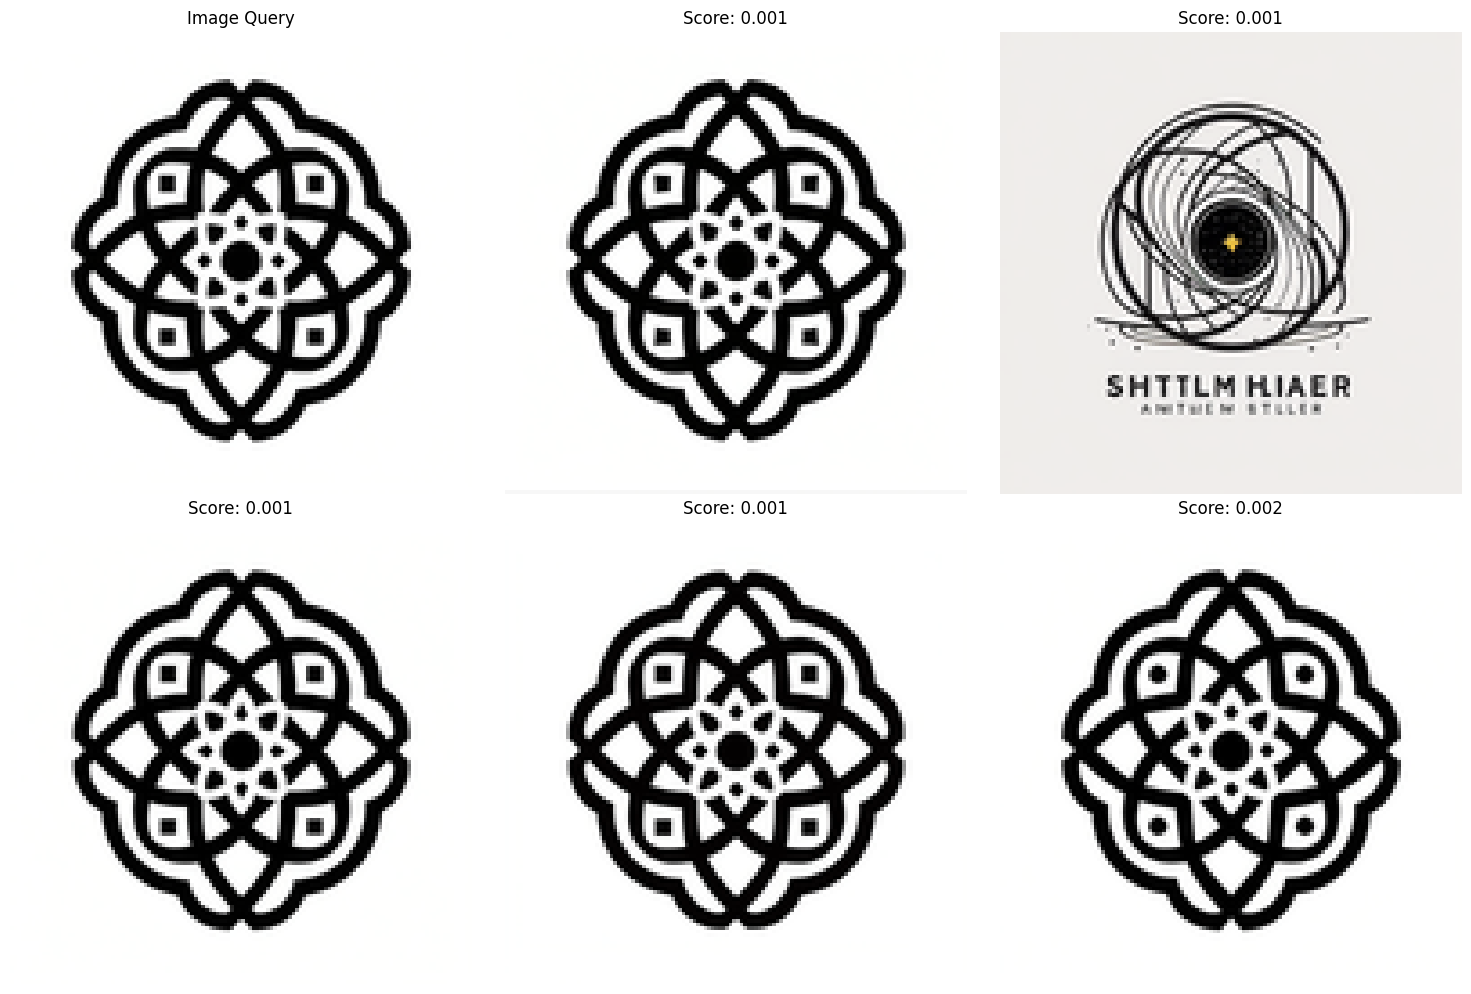

In [ ]:
index = 97334 # 0-355516

image = ds_test_with_embeddings[index]['image']
output = retriever(query_image = image, k = 5, ploting = True)

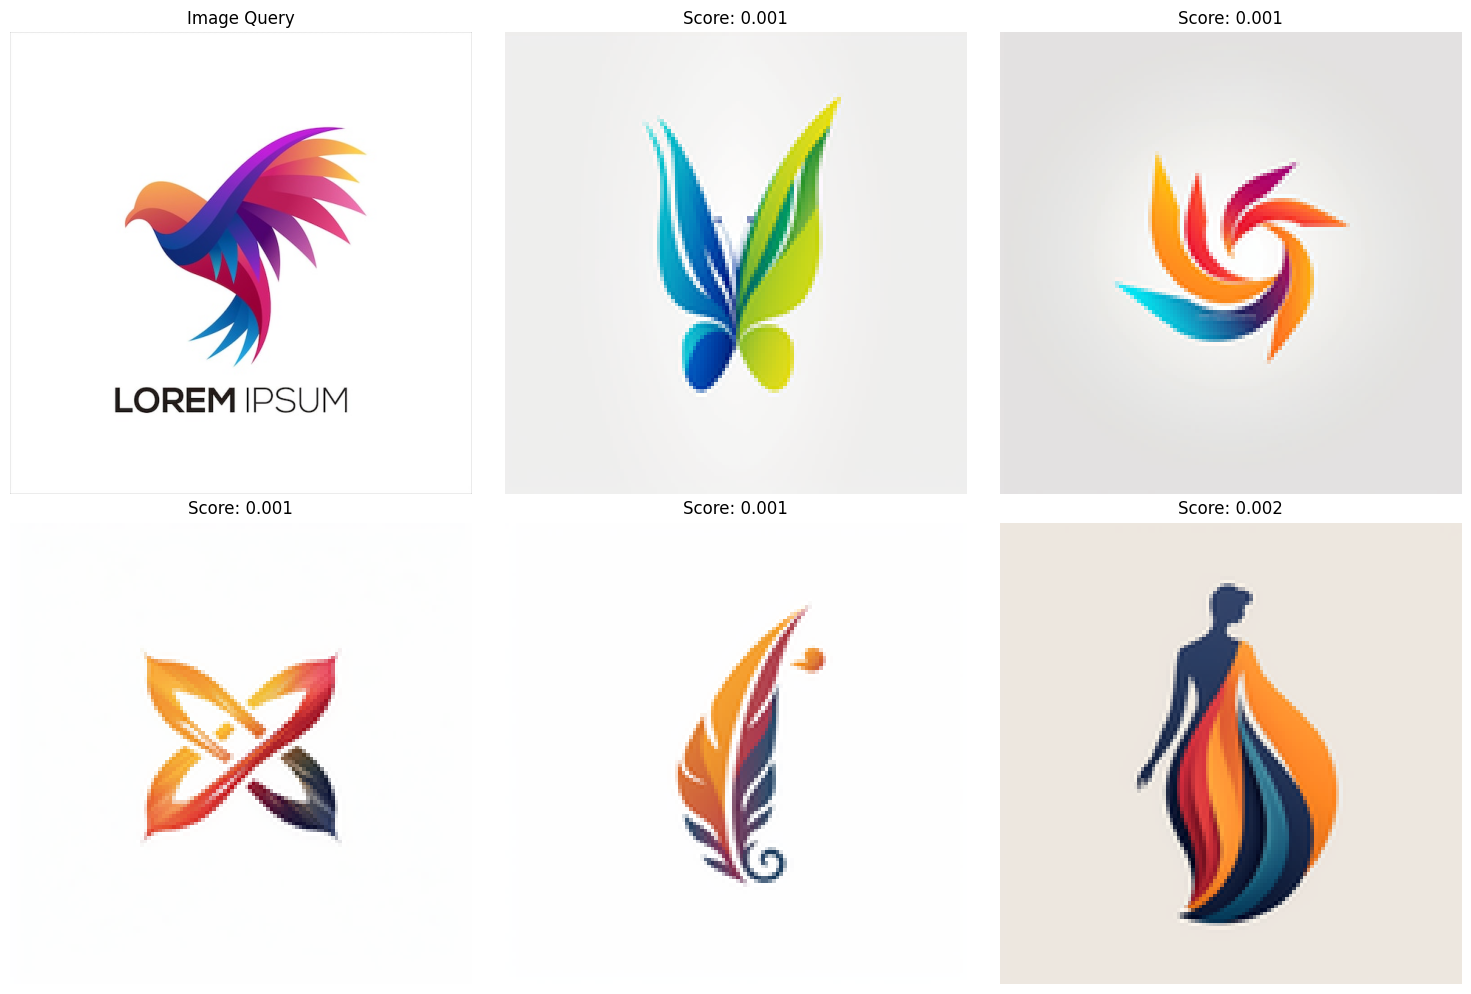

In [ ]:
image_url = "https://img.freepik.com/free-vector/bird-colorful-logo-gradient-vector_343694-1365.jpg"
output = retriever(query_image = image_url, k = 5, ploting = True)

## Disconnect

In [ ]:
# Disconnect and delete the current runtime in Google Colab
from google.colab import runtime

runtime.unassign()